# **Experiment Notebook**



In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

<hr>

## A. Project


In [2]:
group_id = '26'

In [3]:
student_name = 'Max Chew'

In [4]:
student_id = '13552169'

<hr>

<hr>

## B. Data Understanding


In [5]:
data_understanding_executive_summary = 'The purpose of experiment 0 is to gain a preliminary understanding of the dataset, and the variables. This involves several sections and processes including, features selection, data cleaning, features engineering, and preparation for modelling. A baseline model will also be created in order to assess the performance of future experiments. Whilst the dataset being explored only contains records of those customers who are under the age of 25, variables are shared with other datasets which are expected to be merged in later stages before the modelling process. As such, the main goal of this section is focussed on understanding the structure of the data and checking for potential errors as data cleaning and feature engineering as well as exploratory analysis specific to the business use case will be performed in the model training notebook.'

### B.0 Import Packages

In [6]:
# Pandas for data handling
import pandas as pd

# Scikit Learn for ML training
import sklearn

# Altair for plotting
import altair as alt

# seaborn for plotting 
import seaborn as sns

# matplotlib for plotting 
from matplotlib import pyplot as plt

<hr>

### B.1   Load Dataset

young_adults.zip:
https://drive.google.com/file/d/1dJLVhrxWzv5v7G4DTAKH8uI2nRm6K9-R/view?usp=drive_link


In [7]:
#load dataset which was merged earlier on a seperate notebook:
total_Dataset_young_adults=pd.read_csv('total_Dataset_young_adults.csv')

### B.2 Explore Dataset

In [8]:
# get shape of df

total_Dataset_young_adults.shape

(90766, 12)

> Insights: The dataset has 90766rows and, 12 columns. 

In [9]:
# Check information:

total_Dataset_young_adults.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90766 entries, 0 to 90765
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cc_num                90766 non-null  int64  
 1   acct_num              90766 non-null  int64  
 2   trans_num             90766 non-null  object 
 3   unix_time             90766 non-null  int64  
 4   category              90766 non-null  object 
 5   amt                   90766 non-null  float64
 6   is_fraud              90766 non-null  int64  
 7   merchant              90766 non-null  object 
 8   merch_lat             90766 non-null  float64
 9   merch_long            90766 non-null  float64
 10  source_file           90766 non-null  object 
 11  combined_source_file  90766 non-null  object 
dtypes: float64(3), int64(4), object(5)
memory usage: 8.3+ MB


> Insights:
1. The below columns have incorrect attributes and they need to be declared correctly:
 trans_num    90766 non-null  object (Correct: int64)
 unix_time    90766 non-null  object (convert to pd datetime)
 category     90766 non-null  object (Correct: category)

In [10]:
# Check numerical values for any outliers

total_Dataset_young_adults.describe()

,cc_num,acct_num,unix_time,amt,is_fraud,merch_lat,merch_long
count,9.076600e+04,9.076600e+04,9.076600e+04,90766.000000,90766.000000,90766.000000,90766.000000
mean,4.094574e+17,4.417789e+11,1.658646e+09,53.465908,0.004087,36.925948,-95.653120
std,1.324162e+18,3.202142e+11,8.961445e+06,161.911289,0.063803,5.925353,19.347101
min,5.020348e+11,3.418323e+09,1.641474e+09,1.000000,0.000000,20.332546,-160.344143
25%,1.800267e+14,1.673732e+11,1.651327e+09,6.500000,0.000000,33.319343,-110.990627
50%,2.295059e+15,3.868319e+11,1.658656e+09,25.330000,0.000000,38.104640,-91.302910
75%,4.334511e+15,8.058629e+11,1.666833e+09,62.270000,0.000000,41.086849,-80.709271
max,4.986227e+18,9.936159e+11,1.672492e+09,12812.340000,1.000000,49.077236,-72.171352


> Insights: No outliers are observed in numerical columns. No issues.

In [11]:
# Check column names:
total_Dataset_young_adults.columns

Index(['cc_num', 'acct_num', 'trans_num', 'unix_time', 'category', 'amt',
       'is_fraud', 'merchant', 'merch_lat', 'merch_long', 'source_file',
       'combined_source_file'],
      dtype='object')

> Insights: Correct column names as expected. No issues.

In [12]:
# Check for any nul values

for i in total_Dataset_young_adults.columns:
    print(i)
    print(total_Dataset_young_adults[i].isna().sum())


cc_num
0
acct_num
0
trans_num
0
unix_time
0
category
0
amt
0
is_fraud
0
merchant
0
merch_lat
0
merch_long
0
source_file
0
combined_source_file
0


> Insights: Zero null values in each column, as expected. No issues.

In [13]:
# Check for any whitespaces in any position on categorical data
for i in ['category','merchant','source_file']:
    print(i)
    print(total_Dataset_young_adults[i].str.isspace().sum())

category
0
merchant
0
source_file
0


> Insights: Zreo white space entries in categorical columns, as expected. No issues.

In [14]:
# Check for unique values
for i in total_Dataset_young_adults.columns:
    print(i)
    print(len(total_Dataset_young_adults[i].unique()))

cc_num
85
acct_num
85
trans_num
90766
unix_time
90396
category
14
amt
16623
is_fraud
2
merchant
20777
merch_lat
90499
merch_long
90609
source_file
1
combined_source_file
1


> Insights: There are  90766 unique transaction numbers and the dataset has 90766 rows. This means there is no bad data and all transactions are unique. No issues.

In [15]:
#check the contents of the young_adults folder:
for i in os.listdir('/datasets/_deepnote_work/young_adults'):
    for j in os.listdir('/datasets/_deepnote_work/young_adults/'+i):
        dB=pd.read_csv(str('/datasets/_deepnote_work/young_adults/'+i+'/'+j),sep='|')
        print(j,": ", dB.shape)

young_adults_female_rural_000-199.csv :  (0, 10)
young_adults_female_rural_200-399.csv :  (0, 10)
young_adults_female_rural_400-599.csv :  (0, 10)
young_adults_female_rural_600-799.csv :  (0, 10)
young_adults_female_rural_800-999.csv :  (9, 10)
young_adults_female_urban_000-199.csv :  (7893, 10)
young_adults_female_urban_200-399.csv :  (9322, 10)
young_adults_female_urban_400-599.csv :  (7544, 10)
young_adults_female_urban_600-799.csv :  (3580, 10)
young_adults_female_urban_800-999.csv :  (17209, 10)
young_adults_male_rural_000-199.csv :  (0, 10)
young_adults_male_rural_200-399.csv :  (2506, 10)
young_adults_male_rural_400-599.csv :  (2868, 10)
young_adults_male_rural_600-799.csv :  (0, 10)
young_adults_male_rural_800-999.csv :  (1074, 10)
young_adults_male_urban_000-199.csv :  (10768, 10)
young_adults_male_urban_200-399.csv :  (4330, 10)
young_adults_male_urban_400-599.csv :  (6086, 10)
young_adults_male_urban_600-799.csv :  (8255, 10)
young_adults_male_urban_800-999.csv :  (9322, 10)

> Insights: 
The following files do not contain any information. We need to advise the relevant team to address this issue:
young_adults_female_rural_000-199.csv :  (0, 10)
young_adults_female_rural_200-399.csv :  (0, 10)
young_adults_female_rural_400-599.csv :  (0, 10)
young_adults_female_rural_600-799.csv :  (0, 10)
young_adults_male_rural_000-199.csv :  (0, 10)
young_adults_male_rural_600-799.csv :  (0, 10)

all contain no values. whereas the following only contain a small amount of records: 
young_adults_female_rural_800-999.csv :  (9, 10)


> Considerations: 

1. Customer information is not available in these datasets. This is required to build the model efficiently. 

2. Several csv's are have no values. As these csv's refer to customers of specific demographics, they may not serve well as categorical features for future modelling due to class imbalance with other demographics. 

4. The below columns have incorrect attributes and they need to be declared correctly:
     trans_num    232476 non-null  object (Correct: int64)
     unix_time    232476 non-null  object (recommendation: convert to pd datetime)
     category     232476 non-null  object (Correct: category)

> Issues found: 1. no customer data, 2. incorrect attributes in some columns. As explained earlier this is a very preliminary view of the data as the modelling stages will perform a more in depth analysis of the completed dataset, with special consideration of the individual business problem and modelling methods. 

### B.3 Explore Variables of Interest

#### B.3.a Feature "Amount"

> Insights: The majority of  transaction totals occur with a transactional value between $20,000 to $100,000. So Amount is a major factor to be considered for modelling.

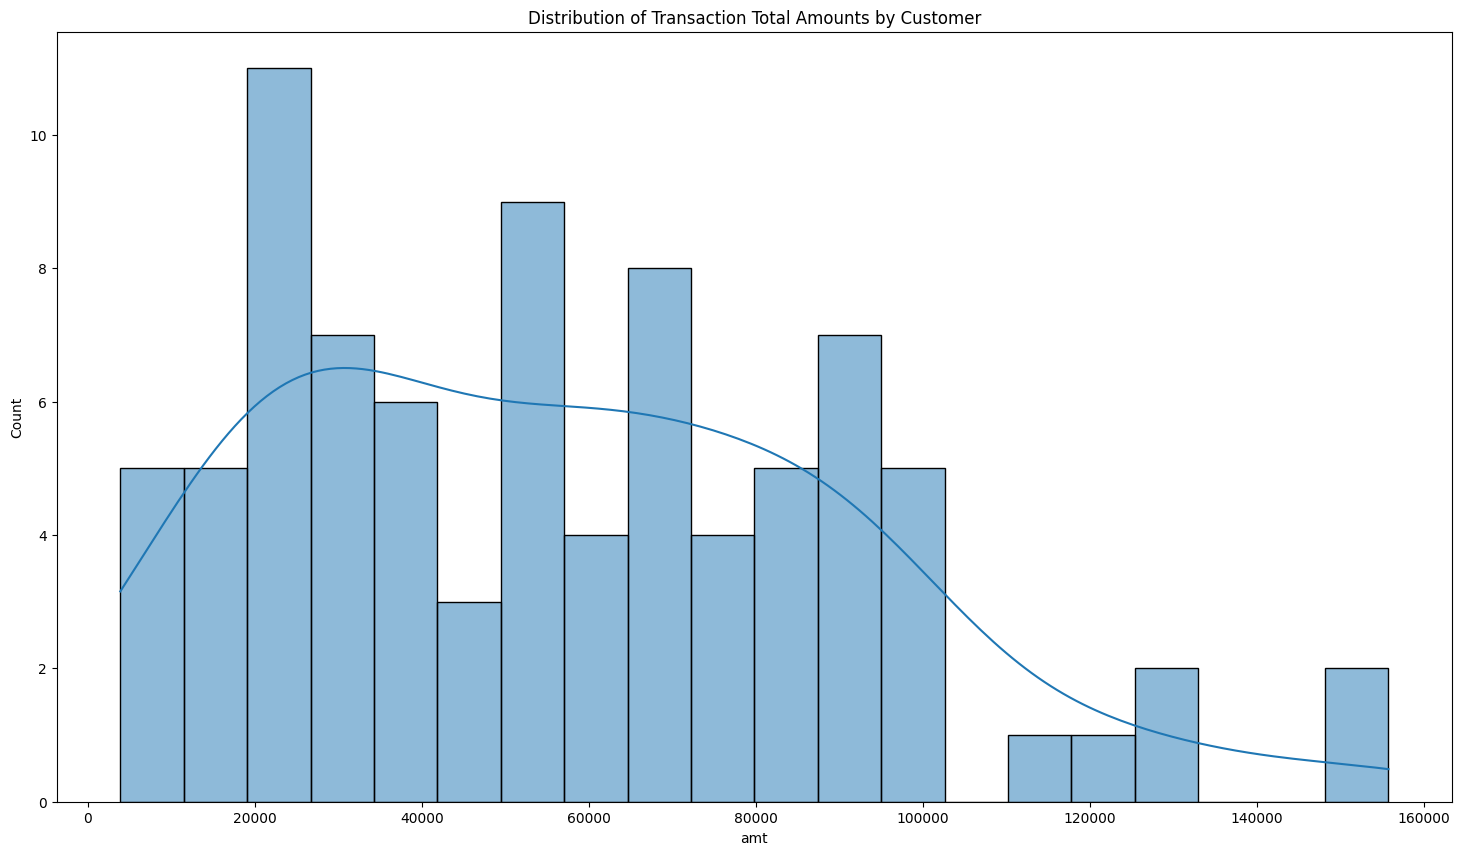

In [30]:
# gruop by acct number
amt_by_category = total_Dataset_young_adults.groupby('acct_num')['amt'].sum().reset_index()

# make bar plot
plt.figure(figsize=(18, 10))
sns.histplot(x='amt', data=amt_by_category, kde=True, bins=20)
plt.title('Distribution of Transaction Total Amounts by Customer')

plt.show()


> Considerations: This distribution may be be representative of the complete dataset to be used later for modelling. It may be interesting at a later stage to compare these distributions of total amounts spent between demographics. 

> Issues found: The data may be more complete when assessing all the transaction data as a whole. For this purpose of modelling, it should be considered that this is only a subset of the final dataset. 

#### B.3.b Feature "category"

> Insights: customers spent different amounts on different categories 

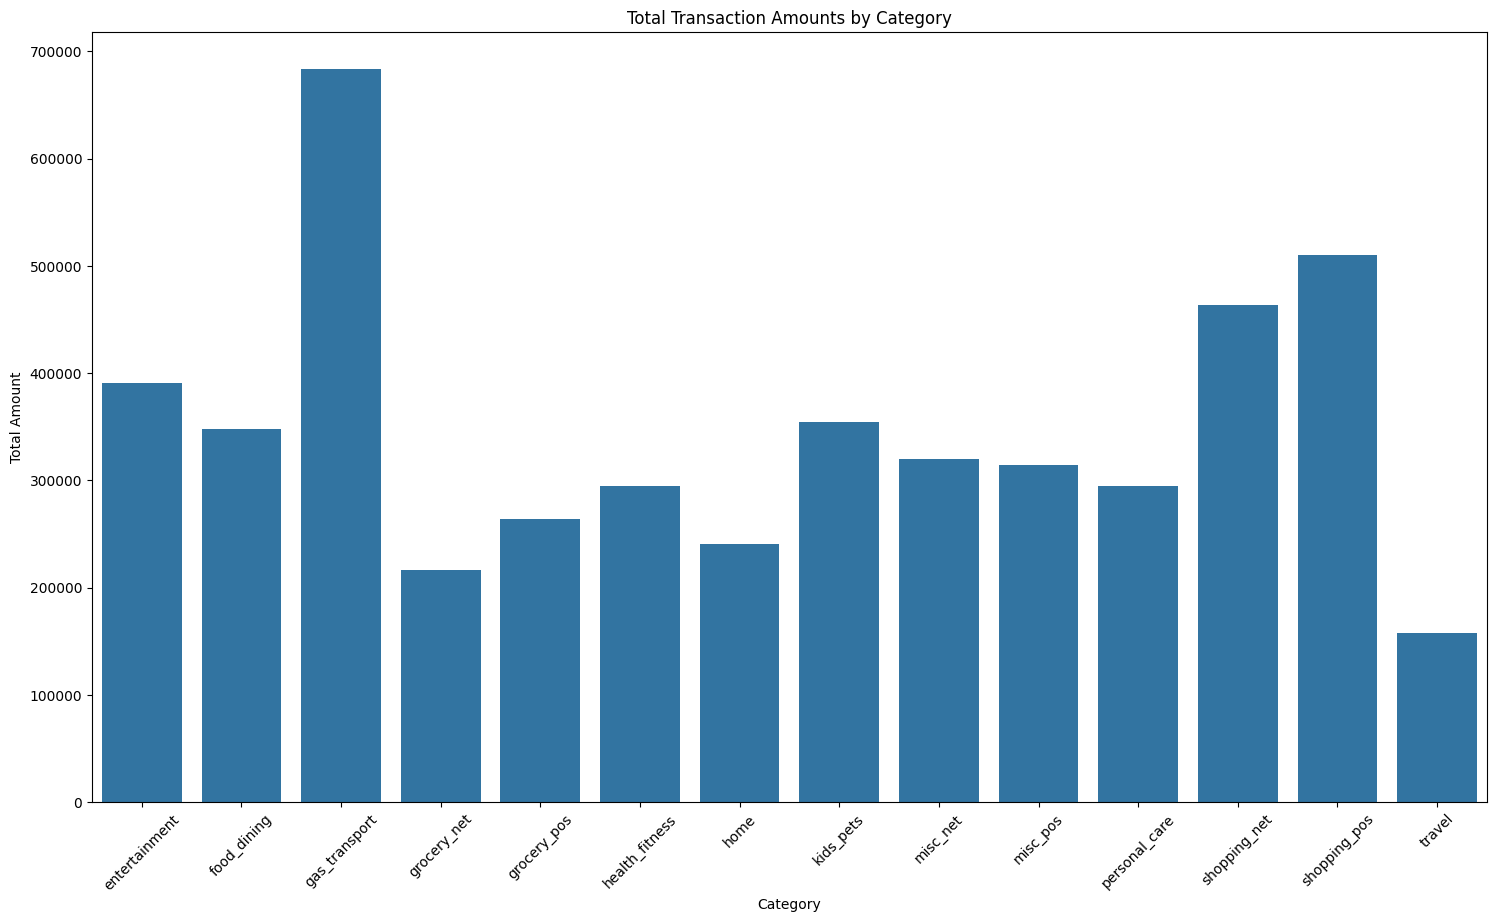

In [18]:
# gruop by cat
amt_by_category = total_Dataset_young_adults.groupby('category')['amt'].sum().reset_index()

# Create the bar plot
plt.figure(figsize=(18, 10))
sns.barplot(x='category', y='amt', data=amt_by_category)
plt.title('Total Transaction Amounts by Category')
plt.xlabel('Category')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.show()


> Considerations: Different categories have different amounts spent. This may be useful as a feature in predicting monthly spend in future modelling.

> Issues found: Further analysis requires customer data. As mentioned throughout the notebook, in order to meet the specific requirements of the model and business use case, a more in depth EDA can be found in the model notebook (36106-AT3-group_26_-_13552169_-Regression for the regression model. In spite of this some insights can be gained from this preliminary look of the data which will both inform a future more in depth EDA as well as the model building process. 

<hr>

## C. Data Cleaning


In [22]:
data_cleaning_executive_summary = '1. The below columns have incorrect attributes and they need to be declared correctly:\n        - trans_num    232476 non-null  object (Correct: int64)\n        - unix_time    232476 non-null  object (recommendation: convert to pd datetime)\n        - category     232476 non-null  object (Correct: category)\n\nFull cleaning of the combined datasets of all transaction datasets as well as the customer dataset, to address the issues above as well as prepare the data specifically for needs of the business use case as well as type of modelling can be found in the model notebooks, specifically in sections D, E F and G of notebook \'36106-AT3-group_26_-_13552169_-Regression\' for the regression analysis.\n\n'

<hr>

## D. Feature Engineering

In [28]:
feature_engineering_executive_summary = 'The requirement of regression model built in \'36106-AT3-group_26_-_13552169_-Regression\' requires the entire transaction dataset as well as the customer dataset. As such, feature engineering specific to the regression problem using the full scope of data can be found in the \'36106-AT3-group_26_-_13552169_-Regression\' notebook specifically in section F for the regression analysis.'

<hr>

## E. Save Datasets

<hr>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=9f5eb710-dbe7-4f5f-8250-9edbd548ca28' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>